# Tutorial: RT-TDHF for hydrogen molecules

This notebook implements the **Hartree--Fock limit** of real-time TDDFT using a **closed-shell H2** as the example.

We will

1. run a **ground-state RHF** calculation with Psi4,
2. build the atomic orbital (AO) integrals with **Psi4 + NumPy**,
3. apply a weak **delta kick** at $t=0$ along the molecular axis,
4. propagate the **field-free time-dependent Fock matrix** with a simple unitary scheme, and
5. use a **conventional NumPy FFT** of the dipole trajectory to obtain the spectrum.

## Equations used in the notebook

For a closed-shell RHF density matrix written as the **total** AO density $P$,


$F[P] = H_{\rm core} + J[P] - \frac{1}{2}K[P].$


We move to an orthogonal AO basis with


$X = S^{-1/2}, \qquad U = S^{1/2},$

$P_{\rm orth} = UPU^T, \qquad F_{\rm orth} = X^T F X.$

At $t=0$ we apply a weak kick along $z$,


$P_{\rm orth}(0^+) =
e^{\, i\kappa \mu_{z,{\rm orth}}}\,
P_{\rm orth}(0^-)\,
e^{- i\kappa \mu_{z,{\rm orth}}}.$

After that, the external field is turned off and we propagate with a unitary transform:

$P(t+\Delta t) \approx
e^{-i\Delta t F(t+\Delta t/2)}
P(t)\,
e^{+i\Delta t F(t+\Delta t/2)}.$

Finally, we compute the induced dipole

$\Delta \mu_z(t)=\mu_z(t)-\mu_z(0)$
and Fourier transform it with `numpy.fft.rfft`.

In [1]:
import numpy as np
import psi4
import matplotlib.pyplot as plt
from scipy.linalg import expm, fractional_matrix_power

# Unit conversions
au_to_fs = 0.024188843265857
hartree_to_ev = 27.211386245988

# Simulation parameters
R_angstrom = 0.74        # H-H bond length
dt = 0.04                # time step in atomic units
nsteps = 12000           # total number of propagation steps
kappa = 1.0e-3           # delta-kick strength (a.u.)
eta = 1.0e-3             # optional exponential damping for FFT (a.u.^-1)

# Make plots a bit larger
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 12

## 1. Ground-state RHF for H2

We place the molecule along the **$z$ axis** and keep the origin at the bond midpoint. With this choice, the ground-state permanent dipole is zero by symmetry.

In [2]:
psi4.core.clean()
psi4.set_memory("1 GB")
psi4.core.set_num_threads(1)
psi4.core.set_output_file("psi4_h2_rt_tdhf.out", False)

mol = psi4.geometry(f'''
units angstrom
nocom
noreorient
symmetry c1
0 1
H 0.0 0.0 {-R_angstrom/2.0}
H 0.0 0.0 {+R_angstrom/2.0}
''')

psi4.set_options({
    "basis": "cc-pvdz",
    "reference": "rhf",
    "scf_type": "pk",
    "e_convergence": 1e-12,
    "d_convergence": 1e-12,
})

E_scf, wfn = psi4.energy("scf", return_wfn=True)
print(f"Ground-state RHF energy = {E_scf:.12f} Eh")


  Memory set to 953.674 MiB by Python driver.
  Threads set to 1 by Python driver.
Ground-state RHF energy = -1.128700093561 Eh


## 2. AO matrices and helper functions

This is the same basic Psi4NumPy workflow used in many small real-time codes:

- overlap matrix $S$,
- one-electron Hamiltonian $H_{\rm core}$,
- AO electron repulsion integrals,
- AO dipole matrices,
- and the symmetric orthogonalizer $S^{-1/2}$.

In [3]:
mints = psi4.core.MintsHelper(wfn.basisset())

S = np.asarray(wfn.S())
Hcore = np.asarray(wfn.H())
ERI = np.asarray(mints.ao_eri())

# Psi4 returns position integrals <chi_mu | x,y,z | chi_nu>.
# The electronic dipole operator is -r, so we add the minus sign here.
x_ao, y_ao, z_ao = [np.asarray(m) for m in mints.ao_dipole()]
mu_x_ao = -x_ao
mu_y_ao = -y_ao
mu_z_ao = -z_ao

# Closed-shell total density P = 2 * D_alpha (density matrix of the alpha electron)
P0 = 2.0 * np.asarray(wfn.Da())

# Symmetric orthogonalization matrices
X = fractional_matrix_power(S, -0.5)
U = fractional_matrix_power(S,  0.5)

# Nuclear dipole (in a.u.); for midpoint-centered H2 this is zero
R_bohr = np.array([[mol.x(A), mol.y(A), mol.z(A)] for A in range(mol.natom())])
Z = np.array([mol.Z(A) for A in range(mol.natom())])
mu_nuc = (Z[:, None] * R_bohr).sum(axis=0)

print("Number of AO functions =", S.shape[0])
print("Ground-state total dipole (a.u.) =", np.trace(P0 @ mu_z_ao).real + mu_nuc[2])

Number of AO functions = 10
Ground-state total dipole (a.u.) = 3.497202527569243e-15


In [4]:
def build_fock(P):
    """Closed-shell RHF Fock matrix built from the total AO density P."""
    J = np.einsum("pqrs,rs->pq", ERI, P, optimize=True)
    K = np.einsum("prqs,rs->pq", ERI, P, optimize=True)
    F = Hcore + J - 0.5 * K
    return 0.5 * (F + F.conj().T)


def ao_to_orth_density(P):
    return U @ P @ U.conj().T


def orth_to_ao_density(P_orth):
    return X @ P_orth @ X.conj().T


def ao_to_orth_operator(A):
    return X.conj().T @ A @ X


def dipole_z(P):
    """Total molecular dipole along z (electrons + nuclei)."""
    return np.trace(P @ mu_z_ao).real + mu_nuc[2]


def rhf_energy(P, F):
    """Closed-shell RHF total energy from the total density P."""
    return 0.5 * np.trace(P @ (Hcore + F)).real + mol.nuclear_repulsion_energy()

## 3. Apply the delta kick at $t=0$

We kick the **electronic dipole operator** along $z$:

$
P_{\rm orth}(0^+) =
e^{\, i\kappa \mu_{z,{\rm orth}}}
P_{\rm orth}(0^-)
e^{- i\kappa \mu_{z,{\rm orth}}}.
$

Because the kick is weak, this is the linear-response regime.

In [5]:
P0_orth = ao_to_orth_density(P0)
mu_z_orth = ao_to_orth_operator(mu_z_ao)

U_kick = expm(1j * kappa * mu_z_orth)
P_kicked_orth = U_kick @ P0_orth @ U_kick.conj().T
P_kicked = orth_to_ao_density(P_kicked_orth)
P_kicked = 0.5 * (P_kicked + P_kicked.conj().T)

print(f"Induced dipole immediately after the kick = {dipole_z(P_kicked): .6e} a.u.")

Induced dipole immediately after the kick =  3.941292e-15 a.u.


## 4. Real-time propagation

To reduce the complixity, we implement both a **naive propagation scheme**.


In [6]:
import numpy as np
from scipy.linalg import expm

def propagate_naive_unitary(P_start_orth, dt, nsteps):
    """Naive first-order RT-TDHF propagation in the orthonormal basis.

    Propagation rule:
        F_n = F[P_n]
        U_n = exp(-i dt F_n)
        P_{n+1} = U_n P_n U_n^dagger

    This is simpler than MMUT because it does not use a midpoint density or
    half-step bootstrap. It is unitary, but only first-order accurate in time
    for nonlinear TDHF.
    """

    # Initial density
    P_orth = P_start_orth.copy()
    P_orth = 0.5 * (P_orth + P_orth.conj().T)

    # Initial AO density and observables
    P_ao = orth_to_ao_density(P_orth)
    P_ao = 0.5 * (P_ao + P_ao.conj().T)

    F_ao = build_fock(P_ao)
    F_ao = 0.5 * (F_ao + F_ao.conj().T)

    times = [0.0]
    dipoles = [dipole_z(P_ao)]
    energies = [rhf_energy(P_ao, F_ao)]

    for step in range(1, nsteps + 1):
        # Fock from the density at the beginning of the step
        P_ao = orth_to_ao_density(P_orth)
        P_ao = 0.5 * (P_ao + P_ao.conj().T)

        F_ao = build_fock(P_ao)
        F_ao = 0.5 * (F_ao + F_ao.conj().T)

        F_orth = ao_to_orth_operator(F_ao)
        F_orth = 0.5 * (F_orth + F_orth.conj().T)

        # Naive full-step unitary propagation
        U_step = expm(-1j * dt * F_orth)
        P_orth = U_step @ P_orth @ U_step.conj().T
        P_orth = 0.5 * (P_orth + P_orth.conj().T)

        # Back to AO basis for analysis
        P_ao = orth_to_ao_density(P_orth)
        P_ao = 0.5 * (P_ao + P_ao.conj().T)

        F_ao = build_fock(P_ao)
        F_ao = 0.5 * (F_ao + F_ao.conj().T)

        times.append(step * dt)
        dipoles.append(dipole_z(P_ao))
        energies.append(rhf_energy(P_ao, F_ao))

    return np.array(times), np.array(dipoles), np.array(energies)

In [7]:
times_au, dipoles_z, energies = propagate_naive_unitary(P_kicked_orth, dt, nsteps)
times_fs = times_au * au_to_fs

print(f"Total propagation time = {times_fs[-1]:.3f} fs")
print(f"Max energy drift       = {np.max(np.abs(energies - energies[0])):.3e} Eh")

Total propagation time = 11.611 fs
Max energy drift       = 9.617e-07 Eh


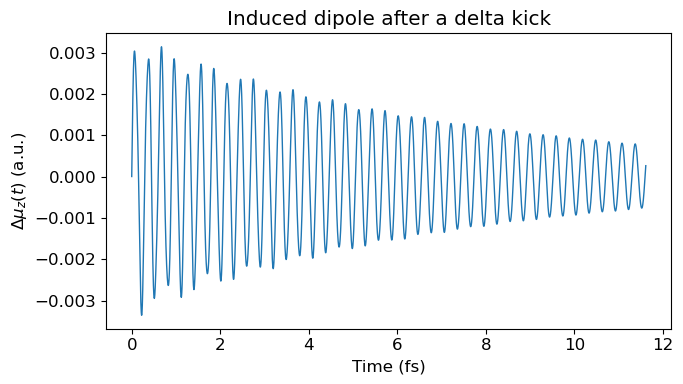

In [8]:
delta_mu = dipoles_z - dipoles_z[0]

plt.plot(times_fs, delta_mu, lw=1.0)
plt.xlabel("Time (fs)")
plt.ylabel(r"$\Delta \mu_z(t)$ (a.u.)")
plt.title("Induced dipole after a delta kick")
plt.tight_layout()
plt.show()

## 5. Conventional NumPy FFT of the dipole trajectory

For a finite trajectory, it is common to multiply the signal by a small damping factor
$
e^{-\eta t}
$
before the FFT. This is optional, but it usually makes the spectrum smoother.

Here we build a simple absorption-like quantity from the same FFT:

$
\alpha_{zz}(\omega) \approx \frac{\Delta t}{\kappa}\,\mathrm{FFT}\!\left[\Delta\mu_z(t)e^{-\eta t}\right],
\qquad
S(\omega)\propto \omega\,\mathrm{Im}\,\alpha_{zz}(\omega).
$

Because `numpy.fft.rfft` uses the standard discrete FFT convention, the code below uses the corresponding sign convention directly.

In [9]:
signal = delta_mu * np.exp(-eta * times_au)

fft_vals = np.fft.rfft(signal)
omega_au = 2.0 * np.pi * np.fft.rfftfreq(signal.size, d=dt)
energy_ev = omega_au * hartree_to_ev

# A simple absorption-like spectrum from the NumPy FFT.
alpha_w = (dt / kappa) * fft_vals
spectrum = omega_au * (-alpha_w.imag)

# Clean up the zero-frequency point and any tiny negative noise
spectrum[0] = 0.0
spectrum = np.clip(spectrum, 0.0, None)

# Normalize for plotting
if spectrum.max() > 0:
    spectrum = spectrum / spectrum.max()

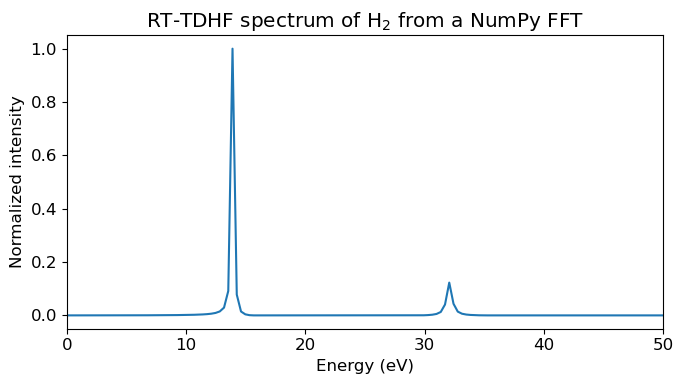

In [10]:
plt.plot(energy_ev, spectrum, lw=1.5)
plt.xlim(0, 50)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized intensity")
plt.title("RT-TDHF spectrum of H$_2$ from a NumPy FFT")
plt.tight_layout()
plt.show()

After real-time calculations, let's examine the excited-state responses of H2 using linear-response TDHF and compare this result with real-time TDHF.

LR-TDHF excitation energy (eV): [13.91137134 21.31926952 32.05653779]
LR-TDHF oscillator strength: [0.53262017 0.         0.13572863]


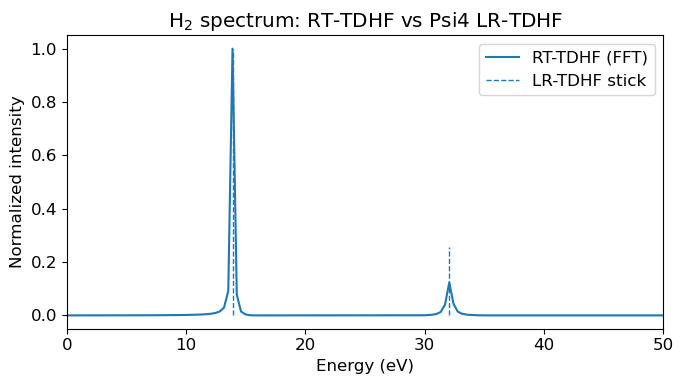

In [11]:
from psi4.driver.procrouting.response.scf_response import tdscf_excitations

psi4.set_options({
    "basis": "cc-pvdz",
    "reference": "rhf",
    "scf_type": "pk",
    "save_jk": True,
})

E_lr, wfn_lr = psi4.energy("scf", return_wfn=True, molecule=mol)
lr_res = tdscf_excitations(wfn_lr, states=3, tda=False)

exc_ev = np.array([r["EXCITATION ENERGY"] for r in lr_res]) * hartree_to_ev
osc = np.array([r["OSCILLATOR STRENGTH (LEN)"] for r in lr_res])

print("LR-TDHF excitation energy (eV):", exc_ev)
print("LR-TDHF oscillator strength:", osc)

plt.plot(energy_ev, spectrum, label="RT-TDHF (FFT)")
plt.vlines(exc_ev, 0, osc/np.max(osc), linestyles="dashed", linewidth=1.0, label="LR-TDHF stick")
plt.xlim(0, 50)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized intensity")
plt.title("H$_2$ spectrum: RT-TDHF vs Psi4 LR-TDHF")
plt.legend()
plt.tight_layout()
plt.show()